# Handwritten Digit Recognition Assignment (U23AI001_assign2)

## Objective
Build and refine Convolutional Neural Networks (CNN) and Multi-Layer Perceptrons (MLP) to classify handwritten digits from the MNIST dataset. The goal is to experiment with activation functions, optimizers, and regularization techniques.

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, datasets
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Check GPU availability
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

2026-01-27 14:17:15.309814: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1769523435.534191      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1769523435.600197      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1769523436.150567      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1769523436.150601      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1769523436.150604      55 computation_placer.cc:177] computation placer alr

Num GPUs Available:  0


2026-01-27 14:17:30.777254: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


## 1. Data Loading and Preprocessing

In [2]:
# Load MNIST dataset
(x_train, y_train), (x_test, y_test) = datasets.mnist.load_data()

# Normalize pixel values to be between 0 and 1
x_train, x_test = x_train / 255.0, x_test / 255.0

# Reshape for CNN (28, 28, 1)
x_train_cnn = x_train.reshape((x_train.shape[0], 28, 28, 1))
x_test_cnn = x_test.reshape((x_test.shape[0], 28, 28, 1))

# One-hot encode labels
y_train_cat = tf.keras.utils.to_categorical(y_train, 10)
y_test_cat = tf.keras.utils.to_categorical(y_test, 10)

print(f"Training data shape: {x_train.shape}")
print(f"CNN training data shape: {x_train_cnn.shape}")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training data shape: (60000, 28, 28)
CNN training data shape: (60000, 28, 28, 1)


## 2. Model Architectures
Defining functions to build the base CNN and MLP architectures with adjustable activation functions and regularization.

In [4]:
def build_cnn(activation='relu', input_shape=(28, 28, 1), use_bn=False, dropout_rate=0.25):
    model = models.Sequential()
    # Conv2D Layer 1
    model.add(layers.Conv2D(32, (3, 3), activation=activation, input_shape=input_shape))

    # Conv2D Layer 2
    model.add(layers.Conv2D(64, (3, 3), activation=activation))

    # Max Pooling
    model.add(layers.MaxPooling2D((2, 2)))

    # Dropout / Batch Normalization logic for Scenario Task
    if dropout_rate > 0:
        model.add(layers.Dropout(dropout_rate))
    
    # Flatten
    model.add(layers.Flatten())
    
    # Dense Layer
    model.add(layers.Dense(128))
    if use_bn:
        model.add(layers.BatchNormalization())
    model.add(layers.Activation(activation))
    
    # Output Layer
    model.add(layers.Dense(10, activation='softmax'))
    
    return model

def build_mlp(activation='relu', input_shape=(28, 28), hidden_layers=[256, 128], use_bn=True):
    model = models.Sequential()
    model.add(layers.Flatten(input_shape=input_shape))
    
    for units in hidden_layers:
        model.add(layers.Dense(units))
        if use_bn:
            model.add(layers.BatchNormalization())
        model.add(layers.Activation(activation))
        
    model.add(layers.Dense(10, activation='softmax'))
    return model

## 3. Helper Functions for Training and Plotting

In [6]:
def train_experiment(model_builder, model_name, config, x_train, y_train, x_test, y_test, epochs=10):
    print(f"Training {model_name}...")
    model = model_builder(**config['build_params'])
    
    optimizer = config.get('optimizer', 'adam')
    model.compile(optimizer=optimizer, 
                  loss='categorical_crossentropy', 
                  metrics=['accuracy'])
    
    history = model.fit(x_train, y_train, epochs=epochs, validation_data=(x_test, y_test), verbose=1)
    return history

def plot_comparison(histories, title="Comparison"):
    plt.figure(figsize=(14, 5))
    
    # Plot Accuracy
    plt.subplot(1, 2, 1)
    for name, hist in histories.items():
        plt.plot(hist.history['val_accuracy'], label=name)
    plt.title(f'{title} - Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    
    # Plot Loss
    plt.subplot(1, 2, 2)
    for name, hist in histories.items():
        plt.plot(hist.history['val_loss'], label=name)
    plt.title(f'{title} - Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    
    plt.show()

## Task 1: The Activation Function Challenge
Comparing Sigmoid, Tanh, and ReLU on the CNN architecture (implied base).

Training CNN_sigmoid...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 76s 39ms/step - accuracy: 0.1058 - loss: 2.3513 - val_accuracy: 0.0974 - val_loss: 2.3099
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 74s 39ms/step - accuracy: 0.1039 - loss: 2.3090 - val_accuracy: 0.0974 - val_loss: 2.3137
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 73s 39ms/step - accuracy: 0.1059 - loss: 2.3090 - val_accuracy: 0.0974 - val_loss: 2.3063
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 73s 39ms/step - accuracy: 0.1033 - loss: 2.3090 - val_accuracy: 0.1135 - val_loss: 2.3064
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 73s 39ms/step - accuracy: 0.1064 - loss: 2.3088 - val_accuracy: 0.0958 - val_loss: 2.3169
Training CNN_tanh...
Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 75s 39ms/step - accuracy: 0.9248 - loss: 0.2495 - val_accuracy: 0.9782 - val_loss: 0.0710
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 73s 39ms/step - accuracy: 0.9807 - loss: 0.0654 - val_accuracy: 0.9788 - val_loss: 0.0673
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 73s 39ms/step - accur

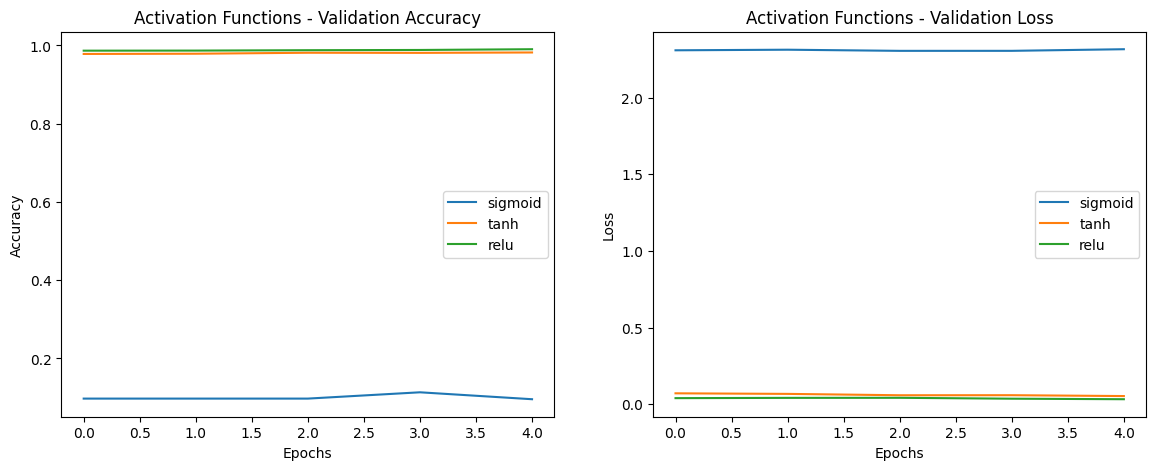

In [7]:
activations = ['sigmoid', 'tanh', 'relu']
task1_results = {}
task1_histories = {}

for act in activations:
    config = {
        'build_params': {'activation': act, 'input_shape': (28, 28, 1)},
        'optimizer': 'adam'  # Keeping optimizer constant for this task
    }
    
    hist = train_experiment(build_cnn, f"CNN_{act}", config, x_train_cnn, y_train_cat, x_test_cnn, y_test_cat, epochs=5)
    task1_histories[act] = hist
    task1_results[f"Activation_{act}"] = hist.history['val_accuracy'][-1]

plot_comparison(task1_histories, title="Activation Functions")

## Task 2: The Optimizer Showdown
Using the best activation (typically ReLU) and comparing SGD, SGD with Momentum, and Adam.

Training CNN_SGD...
Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 67s 35ms/step - accuracy: 0.7574 - loss: 0.7957 - val_accuracy: 0.9394 - val_loss: 0.1984
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 66s 35ms/step - accuracy: 0.9404 - loss: 0.1998 - val_accuracy: 0.9557 - val_loss: 0.1347
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 66s 35ms/step - accuracy: 0.9595 - loss: 0.1411 - val_accuracy: 0.9694 - val_loss: 0.1001
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 66s 35ms/step - accuracy: 0.9688 - loss: 0.1048 - val_accuracy: 0.9767 - val_loss: 0.0747
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 68s 36ms/step - accuracy: 0.9756 - loss: 0.0791 - val_accuracy: 0.9771 - val_loss: 0.0685
Training CNN_SGD_Momentum...
Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 67s 36ms/step - accuracy: 0.8755 - loss: 0.3995 - val_accuracy: 0.9829 - val_loss: 0.0550
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 69s 37ms/step - accuracy: 0.9816 - loss: 0.0588 - val_accuracy: 0.9868 - val_loss: 0.0394
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━

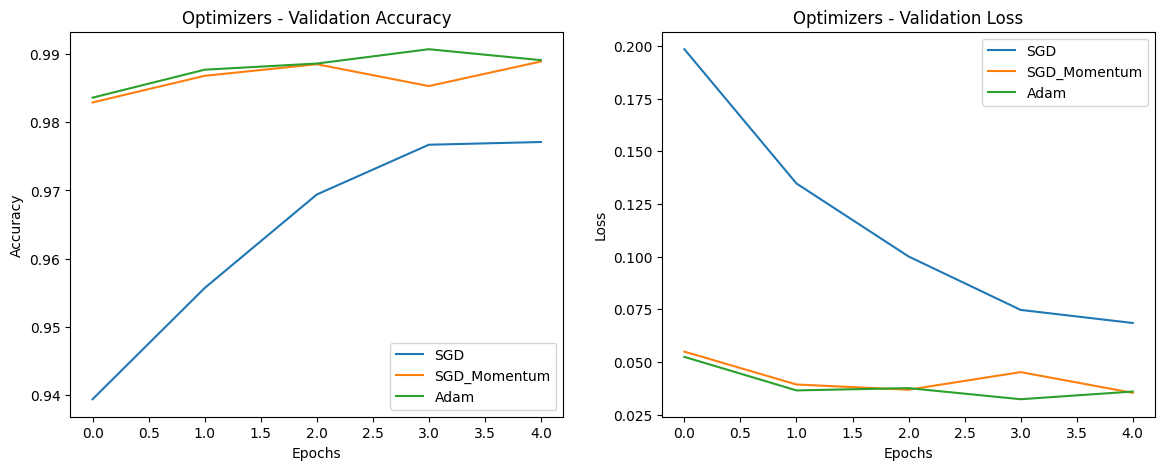

In [8]:
# Define optimizers
optimizers_dict = {
    'SGD': optimizers.SGD(learning_rate=0.01),
    'SGD_Momentum': optimizers.SGD(learning_rate=0.01, momentum=0.9),
    'Adam': optimizers.Adam()
}

task2_results = {}
task2_histories = {}

for opt_name, opt_obj in optimizers_dict.items():
    config = {
        'build_params': {'activation': 'relu', 'input_shape': (28, 28, 1)},
        'optimizer': opt_obj
    }
    
    hist = train_experiment(build_cnn, f"CNN_{opt_name}", config, x_train_cnn, y_train_cat, x_test_cnn, y_test_cat, epochs=5)
    task2_histories[opt_name] = hist
    task2_results[f"Optimizer_{opt_name}"] = hist.history['val_accuracy'][-1]

plot_comparison(task2_histories, title="Optimizers")

## Task 3: Optimization & Regularization Scenarios
Contrasting Batch Normalization and Dropout configurations.

Training No_BN_No_Dropout...
Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 71s 37ms/step - accuracy: 0.9264 - loss: 0.2433 - val_accuracy: 0.9841 - val_loss: 0.0494
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 68s 36ms/step - accuracy: 0.9890 - loss: 0.0361 - val_accuracy: 0.9870 - val_loss: 0.0390
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 68s 36ms/step - accuracy: 0.9929 - loss: 0.0202 - val_accuracy: 0.9889 - val_loss: 0.0369
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 68s 36ms/step - accuracy: 0.9951 - loss: 0.0147 - val_accuracy: 0.9881 - val_loss: 0.0451
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 68s 36ms/step - accuracy: 0.9964 - loss: 0.0109 - val_accuracy: 0.9892 - val_loss: 0.0374
Training No_BN_Dropout_0.1...
Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 73s 38ms/step - accuracy: 0.9208 - loss: 0.2523 - val_accuracy: 0.9866 - val_loss: 0.0431
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 71s 38ms/step - accuracy: 0.9882 - loss: 0.0383 - val_accuracy: 0.9869 - val_loss: 0.0389
Epoch 3/5
1875/1875 ━━━━

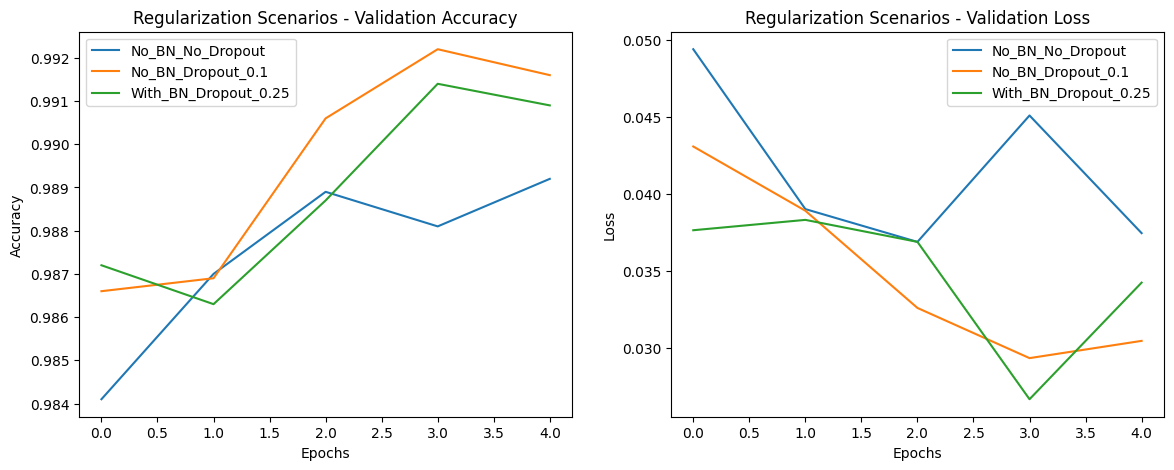

In [9]:
scenarios = [
    {'name': 'No_BN_No_Dropout', 'bn': False, 'dropout': 0.0},
    {'name': 'No_BN_Dropout_0.1', 'bn': False, 'dropout': 0.1},
    {'name': 'With_BN_Dropout_0.25', 'bn': True, 'dropout': 0.25}
]

task3_histories = {}
task3_results = {}

for scenario in scenarios:
    config = {
        'build_params': {
            'activation': 'relu', 
            'input_shape': (28, 28, 1),
            'use_bn': scenario['bn'],
            'dropout_rate': scenario['dropout']
        },
        'optimizer': 'adam'
    }
    
    hist = train_experiment(build_cnn, scenario['name'], config, x_train_cnn, y_train_cat, x_test_cnn, y_test_cat, epochs=5)
    task3_histories[scenario['name']] = hist
    task3_results[scenario['name']] = hist.history['val_accuracy'][-1]

plot_comparison(task3_histories, title="Regularization Scenarios")

## Specific Configurations (CNN-1, MLP-1, MLP-2)
Running the specific model configurations requested.

In [10]:
specific_results = []

# CNN-1: 128 (assuming batch/neurons, using base), Adam, 10 Epochs
cnn1_config = {
    'build_params': {'activation': 'relu', 'input_shape': (28, 28, 1)},
    'optimizer': 'adam'
}
print("Training CNN-1...")
hist_cnn1 = train_experiment(build_cnn, "CNN-1", cnn1_config, x_train_cnn, y_train_cat, x_test_cnn, y_test_cat, epochs=10)
specific_results.append({'Model': 'CNN-1', 'Activation': 'Relu', 'Optimizer': 'Adam', 'Epochs': 10, 'Accuracy': hist_cnn1.history['val_accuracy'][-1]})

# MLP-1: 512-256-128, SGD, 20 Epochs
mlp1_config = {
    'build_params': {'activation': 'relu', 'input_shape': (28, 28), 'hidden_layers': [512, 256, 128], 'use_bn': True},
    'optimizer': 'sgd'
}
print("Training MLP-1...")
hist_mlp1 = train_experiment(build_mlp, "MLP-1", mlp1_config, x_train, y_train_cat, x_test, y_test_cat, epochs=20)
specific_results.append({'Model': 'MLP-1', 'Activation': 'Relu', 'Optimizer': 'SGD', 'Epochs': 20, 'Accuracy': hist_mlp1.history['val_accuracy'][-1]})

# MLP-2: 256, Adam, 15 Epochs
mlp2_config = {
    'build_params': {'activation': 'relu', 'input_shape': (28, 28), 'hidden_layers': [256], 'use_bn': True},
    'optimizer': 'adam'
}
print("Training MLP-2...")
hist_mlp2 = train_experiment(build_mlp, "MLP-2", mlp2_config, x_train, y_train_cat, x_test, y_test_cat, epochs=15)
specific_results.append({'Model': 'MLP-2', 'Activation': 'Relu', 'Optimizer': 'Adam', 'Epochs': 15, 'Accuracy': hist_mlp2.history['val_accuracy'][-1]})

Training CNN-1...
Training CNN-1...
Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 73s 38ms/step - accuracy: 0.9300 - loss: 0.2345 - val_accuracy: 0.9840 - val_loss: 0.0488
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 71s 38ms/step - accuracy: 0.9865 - loss: 0.0430 - val_accuracy: 0.9890 - val_loss: 0.0339
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 71s 38ms/step - accuracy: 0.9915 - loss: 0.0260 - val_accuracy: 0.9907 - val_loss: 0.0304
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 71s 38ms/step - accuracy: 0.9943 - loss: 0.0188 - val_accuracy: 0.9877 - val_loss: 0.0420
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 73s 39ms/step - accuracy: 0.9956 - loss: 0.0142 - val_accuracy: 0.9909 - val_loss: 0.0323
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 73s 39ms/step - accuracy: 0.9965 - loss: 0.0099 - val_accuracy: 0.9907 - val_loss: 0.0344
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 71s 38ms/step - accuracy: 0.9974 - loss: 0.0077 - val_accuracy: 0.9910 - val_loss: 0.0340
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.8278 - loss: 0.6016 - val_accuracy: 0.9586 - val_loss: 0.1478
Epoch 2/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9524 - loss: 0.1722 - val_accuracy: 0.9684 - val_loss: 0.1054
Epoch 3/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9670 - loss: 0.1166 - val_accuracy: 0.9734 - val_loss: 0.0894
Epoch 4/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9742 - loss: 0.0881 - val_accuracy: 0.9762 - val_loss: 0.0809
Epoch 5/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9810 - loss: 0.0687 - val_accuracy: 0.9773 - val_loss: 0.0762
Epoch 6/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9848 - loss: 0.0576 - val_accuracy: 0.9790 - val_loss: 0.0713
Epoch 7/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9867 - loss: 0.0487 - val_accuracy: 0.9810 - val_loss: 0.0670
Epoch 8/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9885 - loss: 0.0410 - 

## Final Comparison Table

In [11]:
results_df = pd.DataFrame(specific_results)
print("Specific Configurations Results:")
print(results_df)

# Aggregating all results for a master table
all_results = []
for k, v in task1_results.items():
    all_results.append({'Experiment': k, 'Value_Type': 'Task 1 (Activation)', 'Accuracy': v})
for k, v in task2_results.items():
    all_results.append({'Experiment': k, 'Value_Type': 'Task 2 (Optimizer)', 'Accuracy': v})
for k, v in task3_results.items():
    all_results.append({'Experiment': k, 'Value_Type': 'Task 3 (Regularization)', 'Accuracy': v})

final_df = pd.DataFrame(all_results)
print("\nTask Experiments Summary:")
print(final_df)

Specific Configurations Results:
   Model Activation Optimizer  Epochs  Accuracy
0  CNN-1       Relu      Adam      10    0.9886
1  MLP-1       Relu       SGD      20    0.9817
2  MLP-2       Relu      Adam      15    0.9804

Task Experiments Summary:
               Experiment               Value_Type  Accuracy
0      Activation_sigmoid      Task 1 (Activation)    0.0958
1         Activation_tanh      Task 1 (Activation)    0.9820
2         Activation_relu      Task 1 (Activation)    0.9903
3           Optimizer_SGD       Task 2 (Optimizer)    0.9771
4  Optimizer_SGD_Momentum       Task 2 (Optimizer)    0.9889
5          Optimizer_Adam       Task 2 (Optimizer)    0.9891
6        No_BN_No_Dropout  Task 3 (Regularization)    0.9892
7       No_BN_Dropout_0.1  Task 3 (Regularization)    0.9916
8    With_BN_Dropout_0.25  Task 3 (Regularization)    0.9909
